# Convolutional Neural Networks

## Google Colab Setup _(use for Google Colab env)_

In [ ]:
!git clone https://github.com/druidmentalized/MIWTutorials.git
import sys

sys.path.append('/content/MIWTutorials/Project4')

## Libraries

In [1]:
from data import load_data, get_dataset
from models import build_model_a, build_model_b, build_model_c, train_model
from utils import plot_history, evaluate_model, show_confusion_matrix, show_misclassified

import tensorflow as tf

## General Setup

In [2]:
RS = 1337
LABELS = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

markers = {
    "a": "Model A",
    "b": "Model B",
    "c": "Model C",
}

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data

In [3]:
(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_data(RS)
dataset = get_dataset(x_train, y_train)

2026-05-11 02:51:46.936073: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-11 02:51:46.936096: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-11 02:51:46.936104: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1778460706.936124 13261273 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778460706.936144 13261273 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. CNN Model

### 2.1 Model A _(1 conv. block)_

In [4]:
model_a = build_model_a()

### 2.2 Model B (n=3 conv. blocks)

In [5]:
model_b = build_model_b()

### Model C _(n=4 conv. blocks + batch normalization)_

In [6]:
model_c = build_model_c()

## 3. Training

In [7]:
history_a = train_model(model_a, dataset, x_val, y_val)
history_b = train_model(model_b, dataset, x_val, y_val)
history_c = train_model(model_c, dataset, x_val, y_val)

Epoch 1/45


2026-05-11 02:52:10.785024: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.2888 - loss: 1.9572 - val_accuracy: 0.4487 - val_loss: 1.5196 - learning_rate: 0.0010
Epoch 2/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.3836 - loss: 1.7284 - val_accuracy: 0.4883 - val_loss: 1.4331 - learning_rate: 0.0010
Epoch 3/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4042 - loss: 1.6948 - val_accuracy: 0.5088 - val_loss: 1.3883 - learning_rate: 0.0010
Epoch 4/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4205 - loss: 1.6503 - val_accuracy: 0.4974 - val_loss: 1.4668 - learning_rate: 0.0010
Epoch 5/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4263 - loss: 1.6407 - val_accuracy: 0.5082 - val_loss: 1.4018 - learning_rate: 0.0010
Epoch 6/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4264 - loss: 1.6391 - val_accuracy: 0.5017 - val_loss: 1.4467 - learning_rate: 0.0010
Epoch 7/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4308 - loss: 1.6265 - val_

### 4.1 Plot

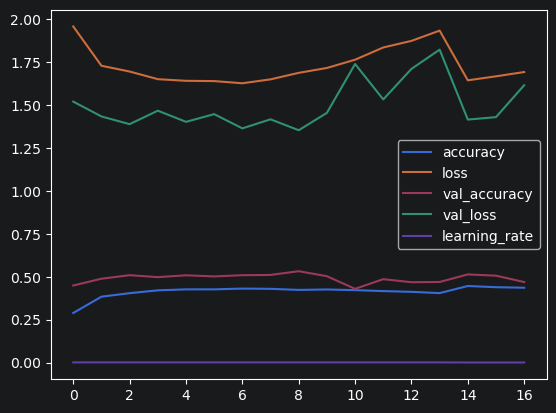

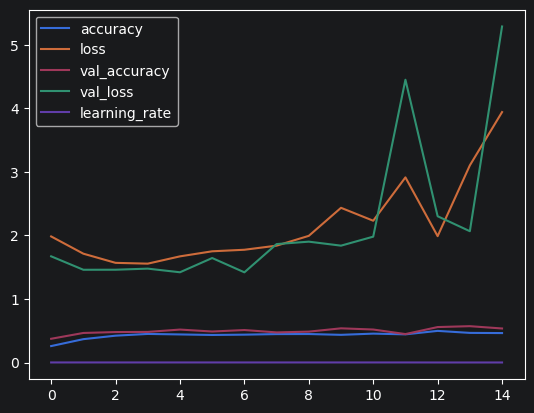

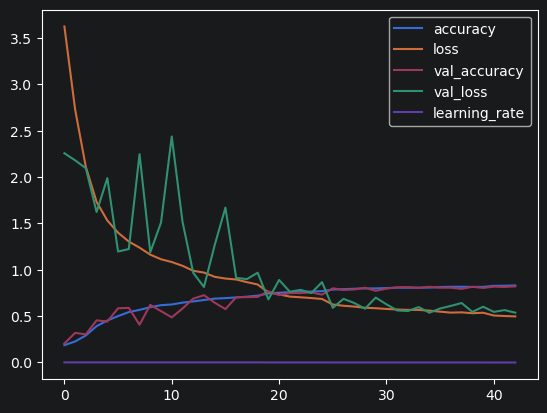

In [8]:
plot_history(history_a, markers["a"])
plot_history(history_b, markers["b"])
plot_history(history_c, markers["c"])

### 4.2 Evaluate

In [9]:
evaluate_model(model_a, x_test, y_test, markers["a"])
evaluate_model(model_b, x_test, y_test, markers["b"])
evaluate_model(model_c, x_test, y_test, markers["c"])

563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5380 - loss: 1.3296
Test loss of Model A: 1.3296122550964355
Test accuracy Model A: 0.5379999876022339
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5136 - loss: 1.4167
Test loss of Model B: 1.4166631698608398
Test accuracy Model B: 0.5136111378669739
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8188 - loss: 0.5394
Test loss of Model C: 0.5393912196159363
Test accuracy Model C: 0.8188333511352539


### 4.3 Confusion Matrix

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 953us/step


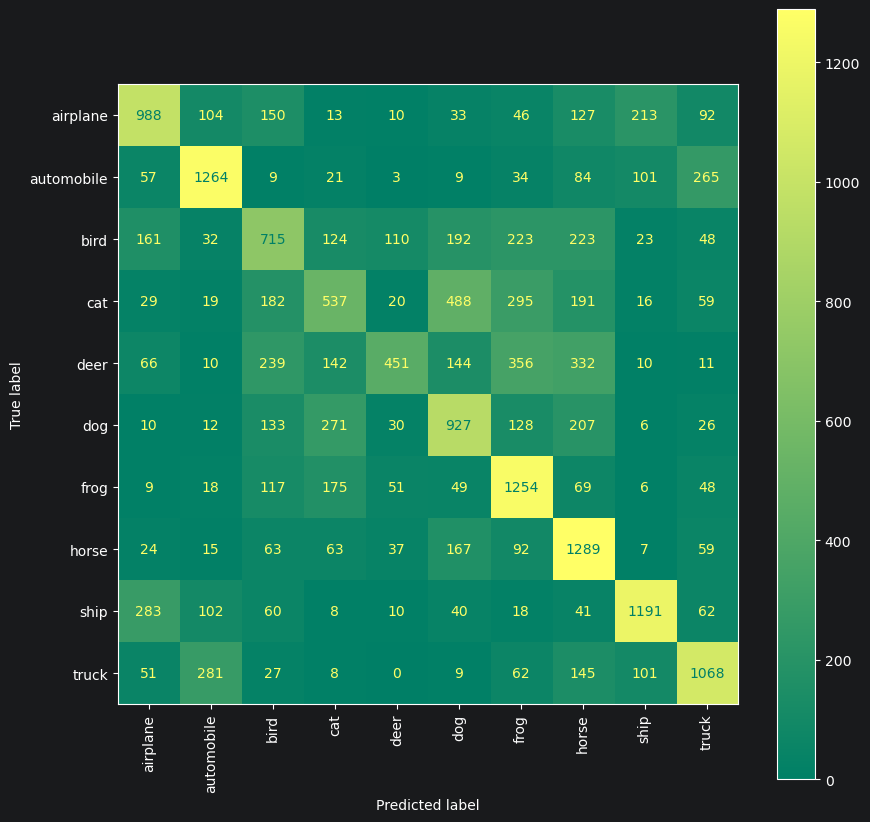

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


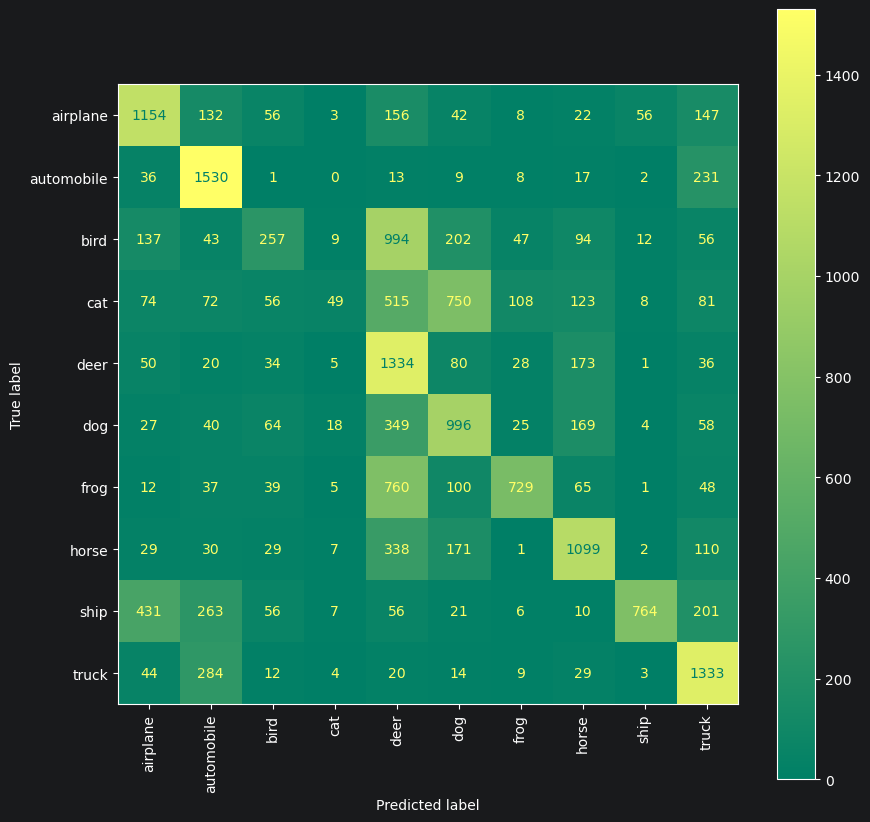

563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


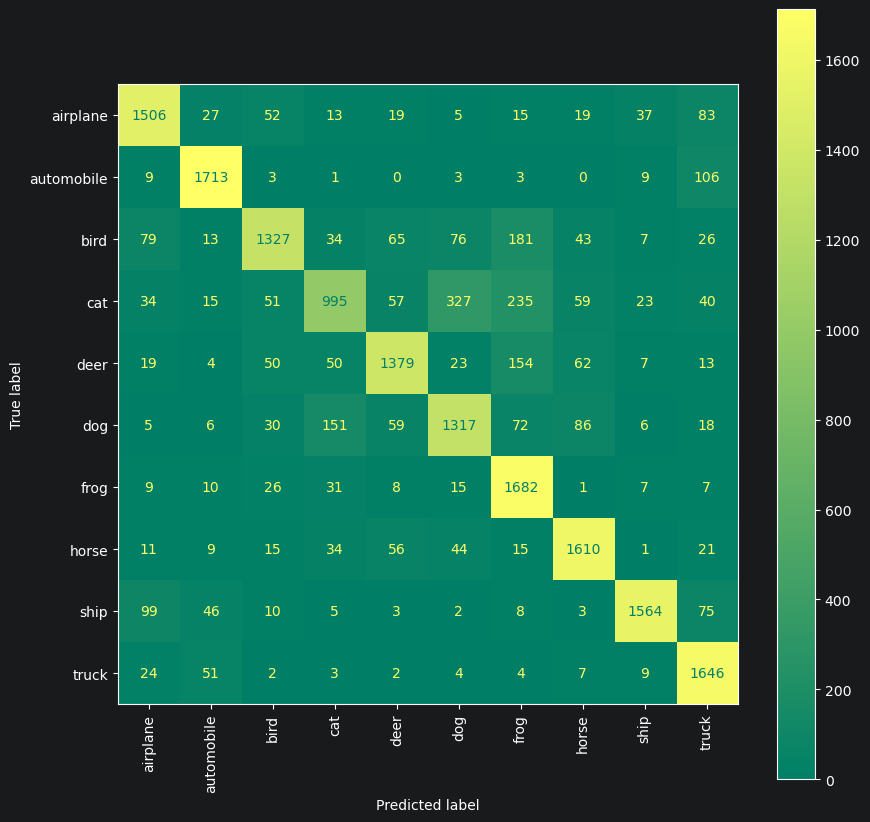

In [10]:
show_confusion_matrix(model_a, x_test, y_test, LABELS, markers["a"])
show_confusion_matrix(model_b, x_test, y_test, LABELS, markers["b"])
show_confusion_matrix(model_c, x_test, y_test, LABELS, markers["c"])

## 5. Analysis

563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step


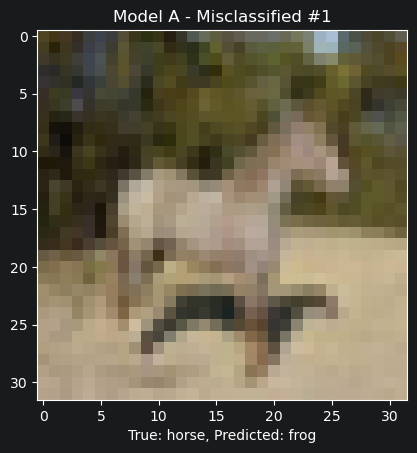

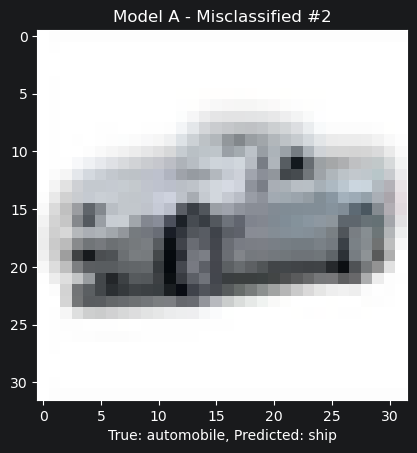

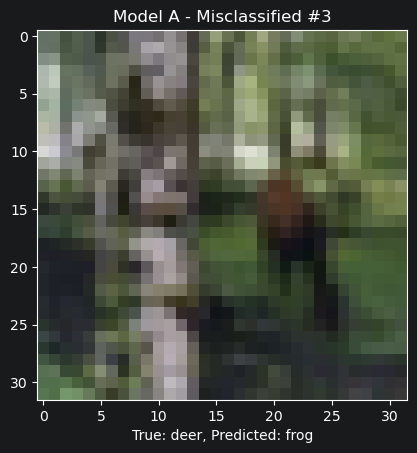

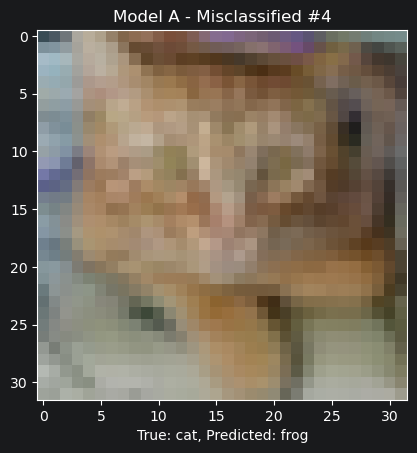

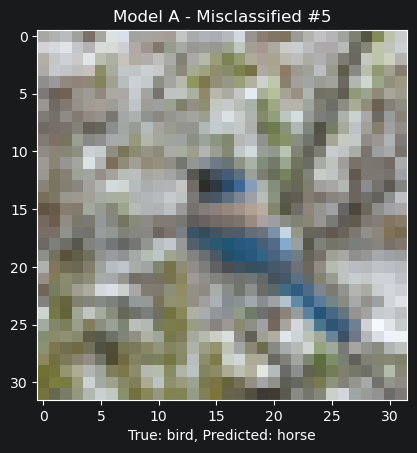

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


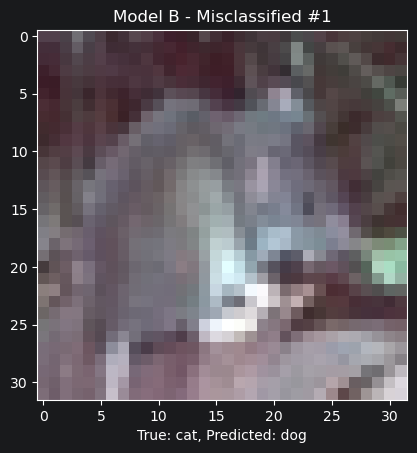

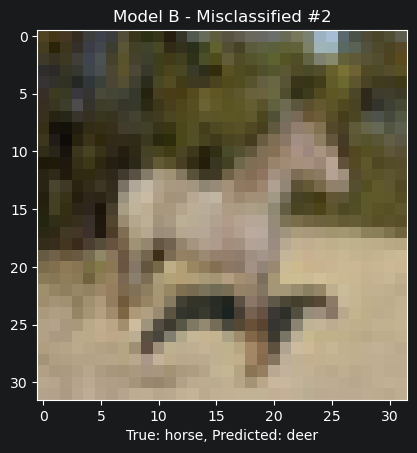

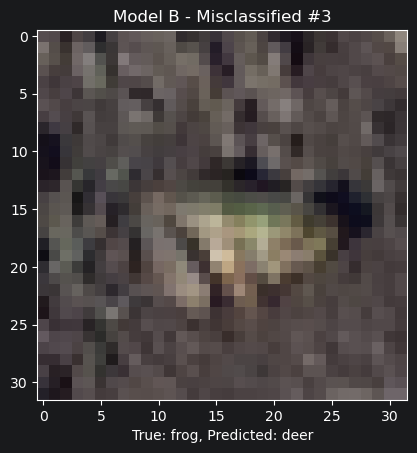

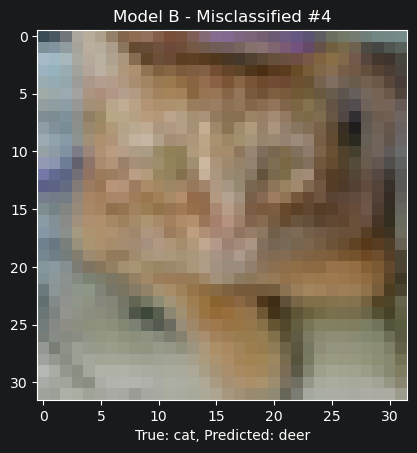

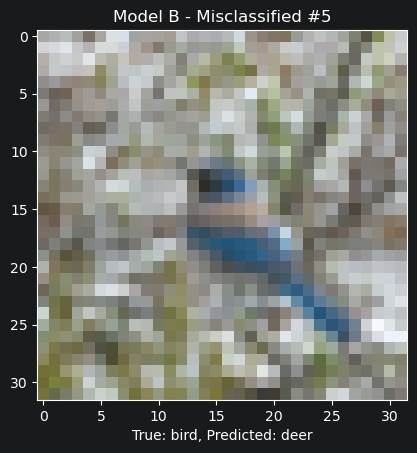

563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


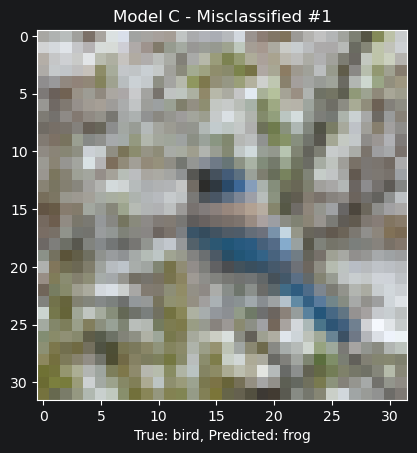

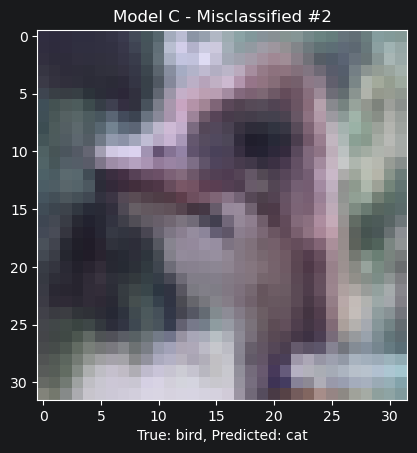

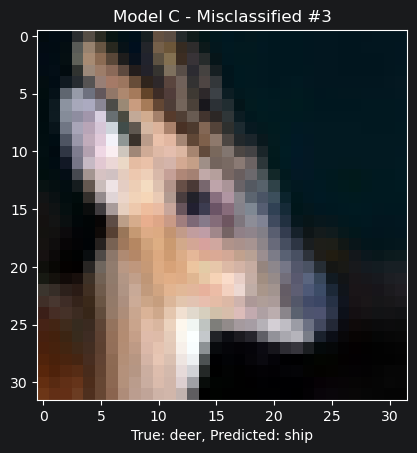

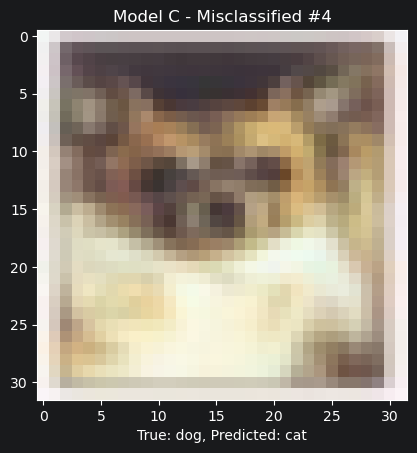

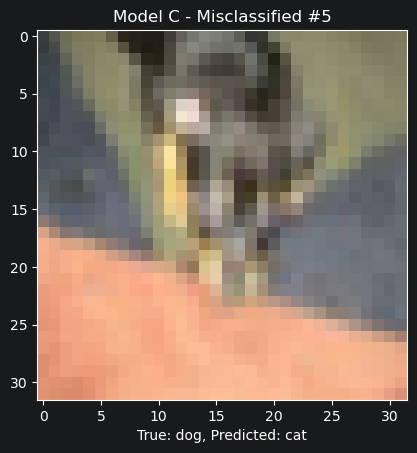

In [11]:
show_misclassified(model_a, x_test, y_test, LABELS, markers["a"])
show_misclassified(model_b, x_test, y_test, LABELS, markers["b"])
show_misclassified(model_c, x_test, y_test, LABELS, markers["c"])

# 6. Conclusions

### 6.1 Best Model
**Model C** is clear winner with accuracy of **0.8188**.

### 6.2 Justification
Model C's superior performance can be attributed to its deeper architecture with 5 convolutional blocks,
which allows it to learn more complex features from the data. Additionally, the inclusion of batch normalization
helps stabilize and accelerate training, leading to better generalization on the test set.

In contrast, Model A's
simpler architecture with only 1 convolutional block may not capture enough features, while Model B, although
deeper than Model A, lacks the benefits of batch normalization, which hinders its performance compared to Model C.